# **TensorFlow GPU Testing**

In [1]:
import tensorflow as tf

print(tf.__version__)
print(tf.keras.__version__)
print(tf.config.list_physical_devices('GPU'))

2025-10-29 15:57:21.795242: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2.20.0
3.11.3
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# **Business Understanding**

## Tujuan

Membangun model **klasifikasi gambar mineral** yang mampu mengenali jenis mineral (misalnya: quartz, calcite, pyrite, dll.) berdasarkan citra mikroskopis atau makro.

## Pertanyaan Bisnis

* Dapatkah sistem otomatis mengidentifikasi jenis mineral dari gambar batuan?
* Seberapa akurat model tersebut dibandingkan dengan identifikasi manual ahli geologi?
* Apakah model bisa membantu percepatan proses eksplorasi mineral?

## Output Bisnis

* Model klasifikasi gambar mineral.
* Dashboard prediksi (opsional).
* Evaluasi akurasi dan confusion matrix untuk interpretasi hasil.

# **Data Understanding**

## **Exploratory Data Analysis**

### **Library Import**

In [2]:
# Library yang sering digunakan
import os, shutil
import zipfile
import random
from random import sample
import shutil
from shutil import copyfile
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm as tq
import matplotlib.pyplot as plt

In [3]:
# Libraries untuk pemrosesan data gambar
import cv2
from PIL import Image
import skimage
from skimage import io
from skimage.transform import resize
from skimage.transform import rotate, AffineTransform, warp
from skimage import img_as_ubyte
from skimage.exposure import adjust_gamma
from skimage.util import random_noise

In [4]:
# Libraries untuk pembangunan model
import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow.keras import Model, layers
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.layers import InputLayer, Conv2D, SeparableConv2D, MaxPooling2D, MaxPool2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.applications.densenet import DenseNet121
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, Callback, EarlyStopping, ReduceLROnPlateau

### **Data Splitting**

In [ ]:
import splitfolders

# folder input = dataset mentah
input_folder = "dataset"

# output = folder hasil split
output_folder = "dataset_split"

# rasio train, val, test (misal 80-10-10)
splitfolders.ratio(
    input_folder,
    output=output_folder,
    seed=42,
    ratio=(.8, .2),
    group_prefix=None, # buat sequence dataset
    move=False # kalau True, file dipindah, kalau False, disalin
)


### **Data Checking**

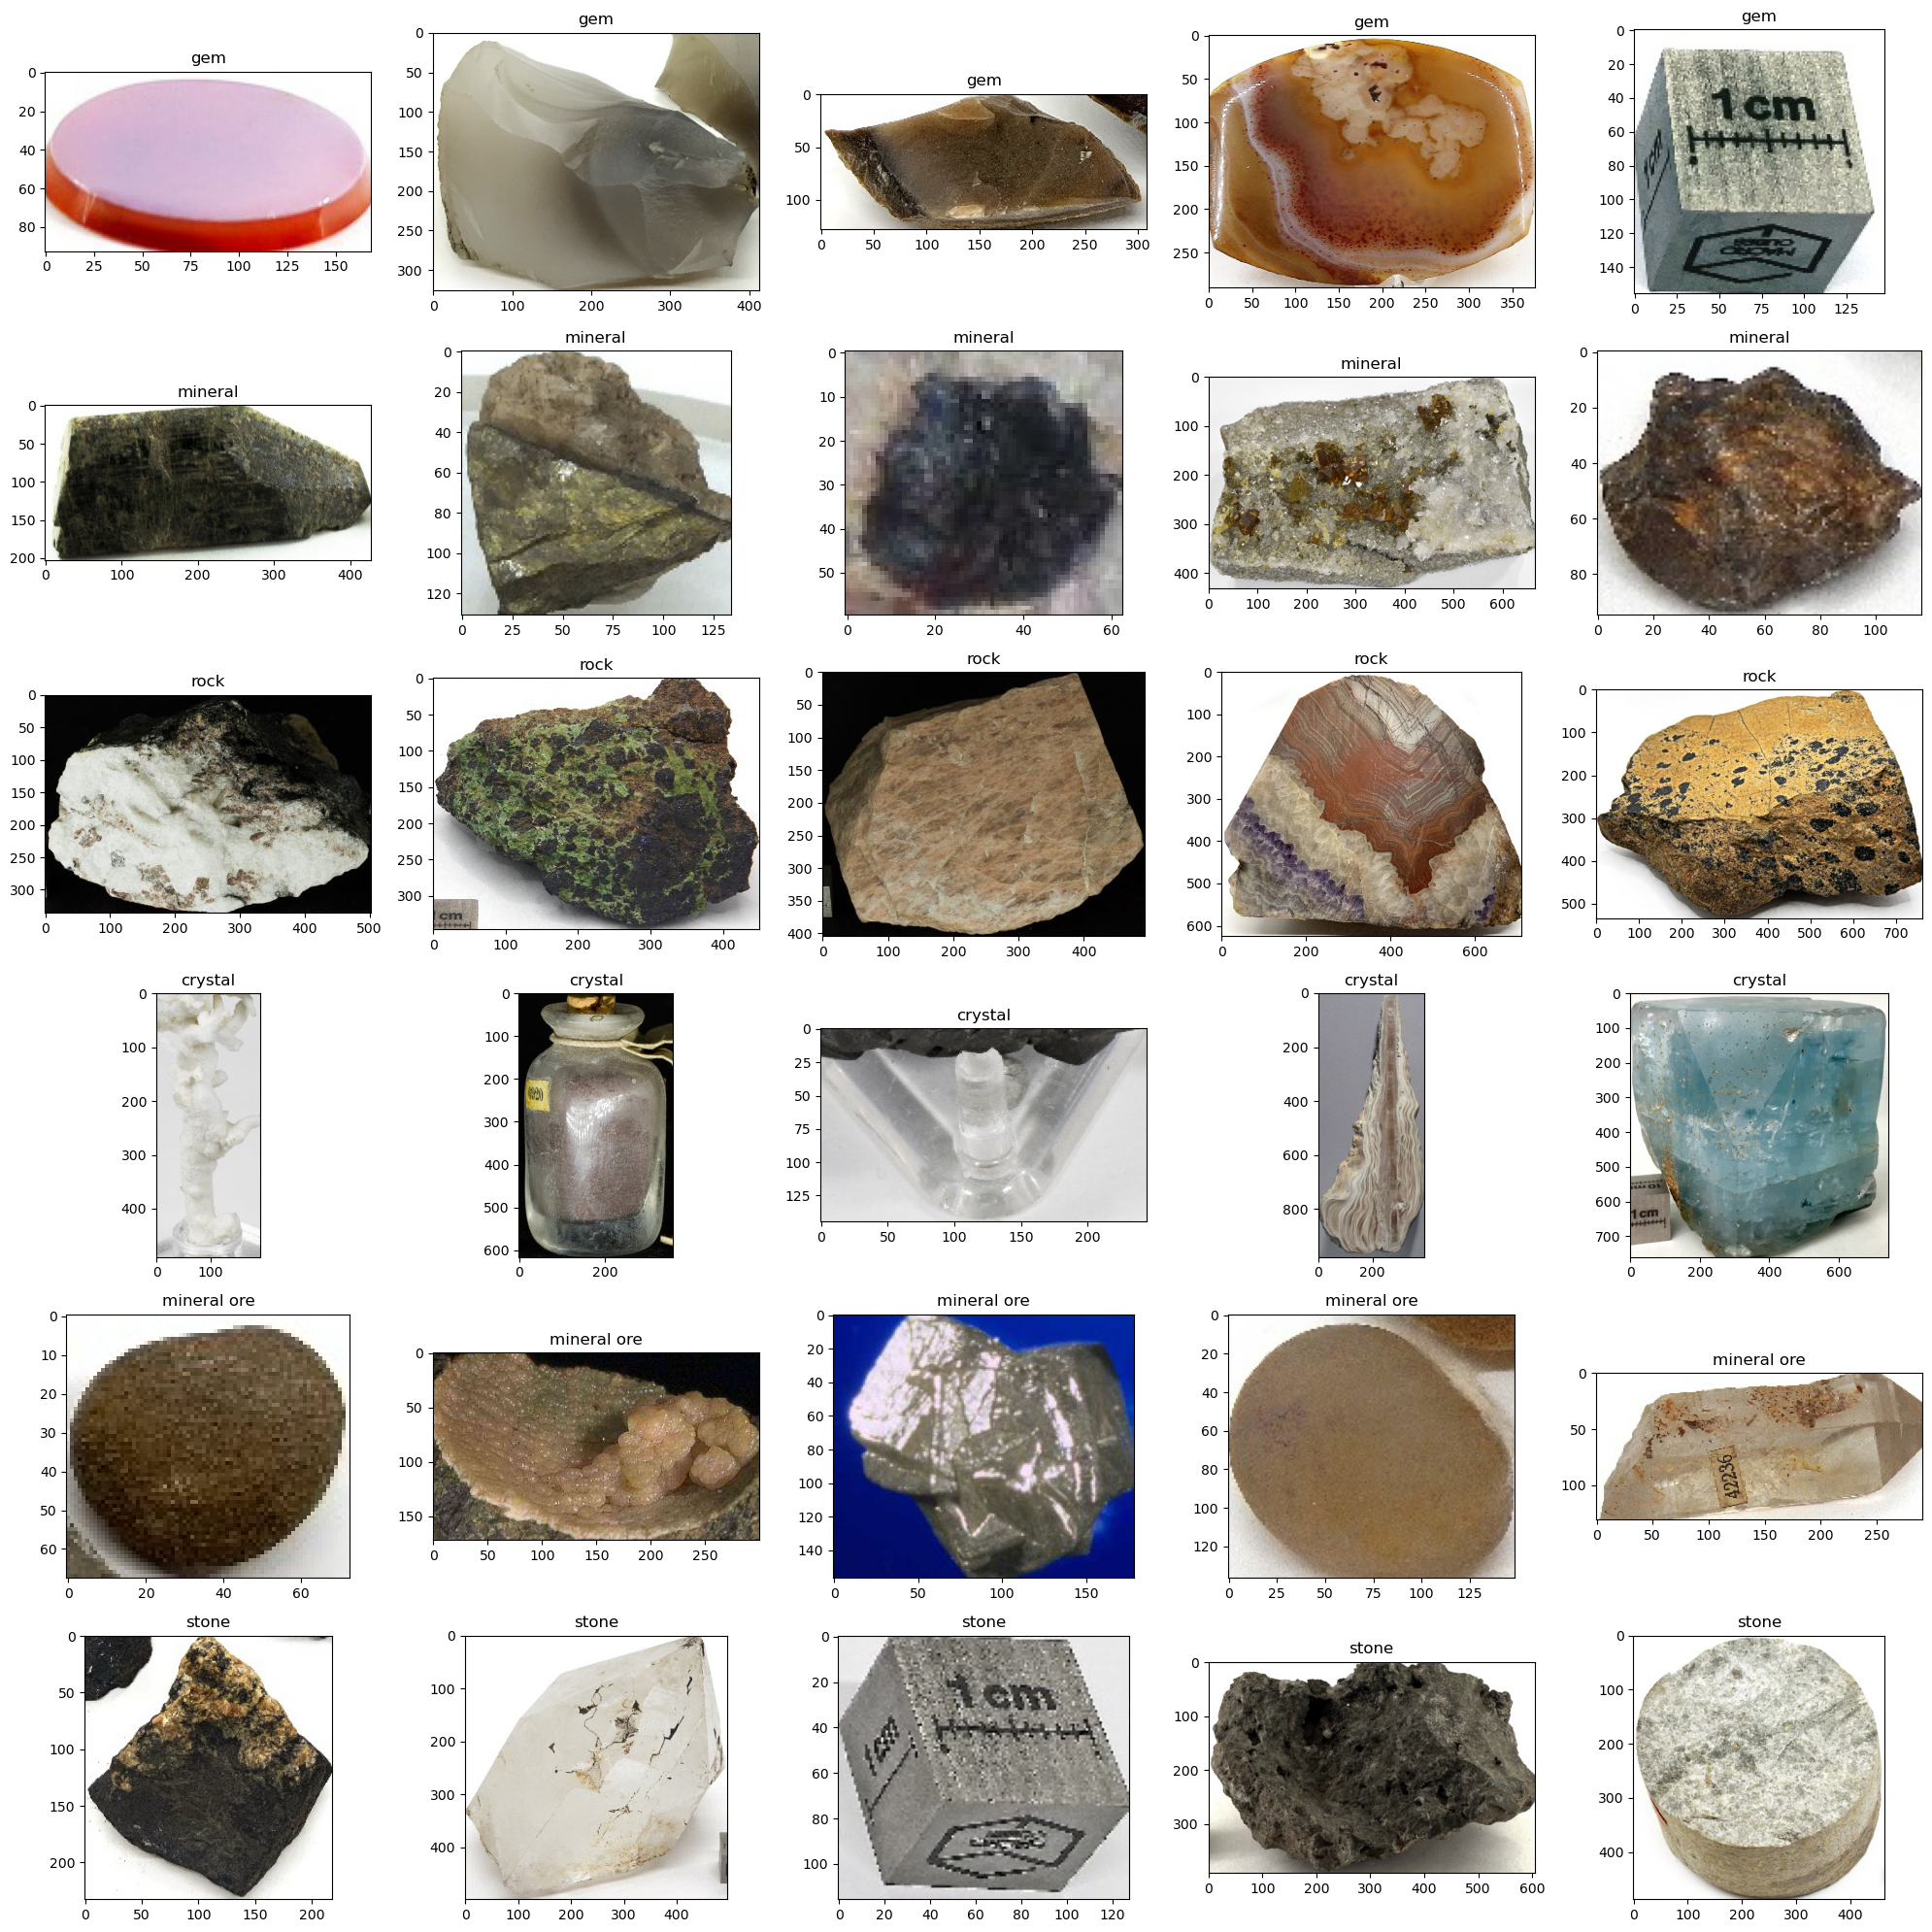

In [8]:
mineral_image = {}

path = "../data/01_raw/mineral-dataset-combined/"
for i in os.listdir(path):
    mineral_image[i] = os.listdir(os.path.join(path, i))

fig, axs = plt.subplots(len(mineral_image.keys()), 5, figsize=(20, 20))

for i, class_name in enumerate(os.listdir(path)):
    images = np.random.choice(mineral_image[class_name], 5, replace=False)

    for j, imaga_name in enumerate(images):
        img_path = os.path.join(path, class_name, imaga_name)
        img = Image.open(img_path)
        axs[i][j].imshow(img)
        axs[i][j].set_title(class_name)

plt.tight_layout()
plt.show()